In [27]:
import matplotlib.pyplot as plt
import numpy as np
import pyref.fitting as fit

from utils.helpers.plotting_helper import set_plotting_defaults
from utils.slab_builders import znpc, surface, contamination, sio2, substrate, vacuum
from utils import read_ooc

set_plotting_defaults()

ooc = read_ooc("dft.csv", material="znpc")

In [32]:
def model(energy, interface_orientation):
    return (
        vacuum(energy)
        | fit.UniTensorSLD(ooc, rotation=np.pi/2, density=1, energy=energy)(200,0)
        | fit.UniTensorSLD(ooc, rotation=interface_orientation, density=1, energy=energy)(5,0)
        | sio2(energy)
        | substrate(energy)
    )

energies = np.arange(282, 290, 0.1)
interface_orientations = np.arange(0, np.pi, np.pi/10)
theta = np.arange(0, 60, .1)
r_s = np.zeros((len(interface_orientations), len(energies), len(theta)))
r_p = np.zeros((len(interface_orientations), len(energies), len(theta)))

for i, interface_orientation in enumerate(interface_orientations):
    for j, energy in enumerate(energies):
        q = 4 * np.pi * np.sin(theta * np.pi/180) / energy
        r = model(energy, interface_orientation).reflectivity(q, energy=energy)
        r_s[i, j] = r[0]
        r_p[i, j] = r[1]

/tmp/ipykernel_2971730/3121322714.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


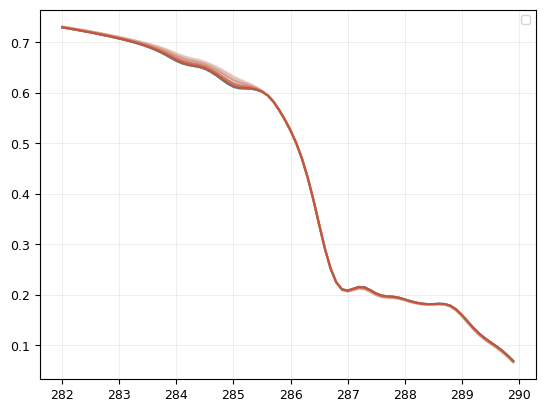

In [35]:
import seaborn as sns

colors = sns.diverging_palette(220, 20, n=len(interface_orientations))

theta_10deg = np.where(theta == 10)[0][0]

fig, ax = plt.subplots()
for i, interface_orientation in enumerate(interface_orientations):
    ax.plot(energies, r_p[i, :, theta_10deg], color=colors[i])
ax.legend()
plt.show()
